In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #daf1a1; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #002762">Stability of the P1-iso-P1 Method</h3>
</div>

Imports:

In [2]:
from scipy.sparse.linalg import splu
from scipy.linalg import eigh
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import *
from Utilities.Plot_functions import *


---

<div style="background-color: #f1e2a1; color: white; padding: 10px; border-radius: 0px;">
<h3 style="margin: 0;  color: #002762">Ladyzhenskaya–Babuška–Brezzi (LBB) Condition:</h3>
</div>

The LBB (inf-sup) condition is a necessary and sufficient stability criteria for saddle-point problems (like the Stokes equations) to ensure a unique, stable solution.

### 1. Continuous Definition
Velocity space $V$ and pressure space $Q$ must satisfy:
$$\exists \beta>0: \quad \inf_{q \in Q \setminus \{0\}} \space \sup_{v \in V \setminus \{0\}} \left(\frac{\int_{\Omega}q(\nabla \cdot v)d\Omega}{\|v\|_{V}\cdot\|q\|_{Q}}\right) \ge \beta$$

### 2. Discrete Algebraic System
Mapping continuous fields to nodal vectors ($\mathbf{u} \in \mathbb{R}^{2N_v}$, $\mathbf{p} \in \mathbb{R}^{N_p}$) yields the discrete inf-sup framework:

$$\exists \beta>0: \quad \inf_{\mathbf{p} \not= \mathbf{0}} \space \sup_{\mathbf{u} \not= \mathbf{0}} \left(\frac{\mathbf{p}^T \mathbf{B} \mathbf{u}}{\left(\mathbf{u}^T \mathbf{M}_v \mathbf{u}\right)^{1/2} \cdot \left(\mathbf{p}^T \mathbf{M}_p \mathbf{p}\right)^{1/2}}\right) \ge \beta$$

Where:
* **$\mathbf{B} = [\mathbf{B}_x \quad \mathbf{B}_y]$**: Discrete divergence matrix coupling pressure and velocity.
* **$\mathbf{M}_v = \begin{bmatrix} \mathbf{A} & \mathbf{0} \\ \mathbf{0} & \mathbf{A} \end{bmatrix}$**: Velocity energy weight matrix ($\mathbf{A}$ is the discrete Laplacian).
* **$\mathbf{M}_p$**: Pressure mass matrix accounting for spatial overlap of pressure basis functions.

### 3. Practical Stability Test (Generalized Eigenvalue Problem)
Maximizing over $\mathbf{u}$ and minimizing over $\mathbf{p}$ via the Rayleigh quotient transforms the condition into a straightforward matrix eigenvalue problem:

$$\exists \beta>0: \quad \sqrt{\lambda_{min}\left(\mathbf{M}_p^{-1}\left( \mathbf{B}_x \mathbf{A}^{-1} \mathbf{B}_x^T + \mathbf{B}_y \mathbf{A}^{-1} \mathbf{B}_y^T \right)\right)} \ge \beta$$

#### Grid Verification Rules:
* **Stable Grid Combinations:** As the mesh size $h \to 0$, the minimum eigenvalue $\lambda_{\min}$ bounds away from zero ($\lambda_{\min} \ge \beta^2 > 0$).
* **Unstable Grid Combinations:** As the mesh size $h \to 0$, $\lambda_{\min} \to 0$, indicating spurious pressure oscillations (checkerboard patterns).


---

Loading Data & Taking Look at the Mesh:

In [3]:
data = np.load('Meshes/LBB_test_mesh_data.npz')
p_raw = data['p']
tri_idx = data['t_raw']
data.close()

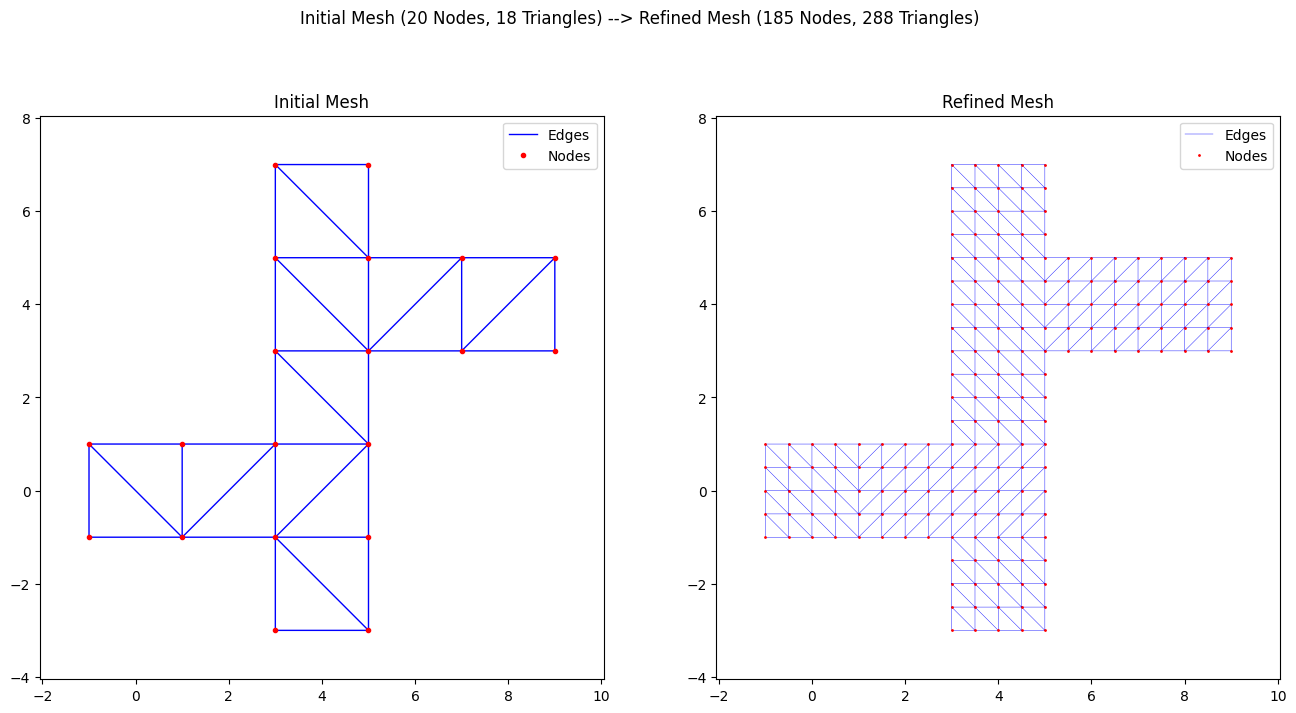

In [4]:
_ = Plot_Initial_Refined_meshes('Meshes/LBB_test_mesh_data.npz', num_of_refinements=2)

Calculating    $\quad \mathbf{M}_p^{-1}, \quad \mathbf{A}^{-1}, \quad \mathbf{B}_x, \quad \mathbf{B}_y$:

In [5]:
p_original, e_original, t_original = build_stable_mesh(p_raw, tri_idx)

n_levels = 6

results = {
    'level': [],
    'H': [],
    'Nv': [],
    'Np': [],
    'lambda_min': [],
    'lambda_second': [],
}

print('_' * 70)
for i in range(n_levels):
    p_coarse, e_coarse, t_coarse = refine_n_times(p_original, e_original, t_original,
                                                    number_of_refinements=i)
    p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

    Nv = p_fine.shape[0]
    Np = p_coarse.shape[0]

    print(f'Level {i}:')
    print(f'  Coarse grid shapes: p {p_coarse.shape}, e {e_coarse.shape}, t {t_coarse.shape}')
    print(f'  Fine grid shapes:   p {p_fine.shape}, e {e_fine.shape}, t {t_fine.shape}')

    M_p = calculate_mass_M(p_coarse, t_coarse)
    B_x, B_y = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
    A = calculate_velocity_A(p_fine, t_fine, kinematic_viscosity=1.0)

    print(f'  Matrix shapes: M_p {M_p.shape}, Bx {B_x.shape}, By {B_y.shape}, A {A.shape}')

    A_lu = splu(A.tocsc())

    Ainv_BxT = A_lu.solve(B_x.toarray().T)
    Ainv_ByT = A_lu.solve(B_y.toarray().T)

    K = B_x @ Ainv_BxT + B_y @ Ainv_ByT
    K = 0.5 * (K + K.T)  # symmetrize away LU round-off

    eigvals = eigh(K, M_p.toarray(), subset_by_index=[0, 1], eigvals_only=True)
    eigvals = np.sort(np.abs(eigvals))

    tol = 1e-10 * max(eigvals[-1], 1.0)
    nonzero = eigvals[eigvals > tol]
    lambda_min = nonzero[0] if len(nonzero) > 0 else eigvals[0]

    beta = np.sqrt(lambda_min)
    print(f'  smallest two eigenvalues: {eigvals}')
    print(f'  lambda_min = {lambda_min:.6e}  ->  beta = {beta:.6e}')
    print('_' * 70)

    results['level'].append(i)
    results['H'].append(1 / 2**i)
    results['Nv'].append(Nv)
    results['Np'].append(Np)
    results['lambda_min'].append(lambda_min)
    results['lambda_second'].append(eigvals[1] if len(eigvals) > 1 else np.nan)


______________________________________________________________________
Level 0:
  Coarse grid shapes: p (20, 2), e (37, 3), t (18, 7)
  Fine grid shapes:   p (57, 2), e (128, 3), t (72, 7)
  Matrix shapes: M_p (20, 20), Bx (20, 57), By (20, 57), A (57, 57)
  smallest two eigenvalues: [0.70467254 0.72701555]
  lambda_min = 7.046725e-01  ->  beta = 8.394478e-01
______________________________________________________________________
Level 1:
  Coarse grid shapes: p (57, 2), e (128, 3), t (72, 7)
  Fine grid shapes:   p (185, 2), e (472, 3), t (288, 7)
  Matrix shapes: M_p (57, 57), Bx (57, 185), By (57, 185), A (185, 185)
  smallest two eigenvalues: [0.68014725 0.68586604]
  lambda_min = 6.801473e-01  ->  beta = 8.247104e-01
______________________________________________________________________
Level 2:
  Coarse grid shapes: p (185, 2), e (472, 3), t (288, 7)
  Fine grid shapes:   p (657, 2), e (1808, 3), t (1152, 7)
  Matrix shapes: M_p (185, 185), Bx (185, 657), By (185, 657), A (657, 65

Finding $\lambda_i$:

$$
\lambda_{min}\left(\mathbf{M}_p^{-1}\left( \mathbf{B}_x \mathbf{A}^{-1} \mathbf{B}_x^T + \mathbf{B}_y \mathbf{A}^{-1} \mathbf{B}_y^T \right)\right) \ge \beta^2 > 0
$$

In [6]:
df = pd.DataFrame(
    {
        "Level": results["level"],
        "Nv": results["Nv"],
        "Np": results["Np"],
        "λmin": results["lambda_min"],
    }
)

df["β"] = np.sqrt(df["λmin"])
df["∆λmin"] = df["λmin"].diff()

pd.options.display.float_format = "{:.2e}".format
df

,Level,Nv,Np,λmin,β,∆λmin
0,0,57,20,7.05e-01,8.39e-01,NaN
1,1,185,57,6.80e-01,8.25e-01,-2.45e-02
2,2,657,185,6.66e-01,8.16e-01,-1.43e-02
3,3,2465,657,6.58e-01,8.11e-01,-8.20e-03
4,4,9537,2465,6.54e-01,8.09e-01,-3.93e-03
5,5,37505,9537,6.52e-01,8.08e-01,-1.58e-03


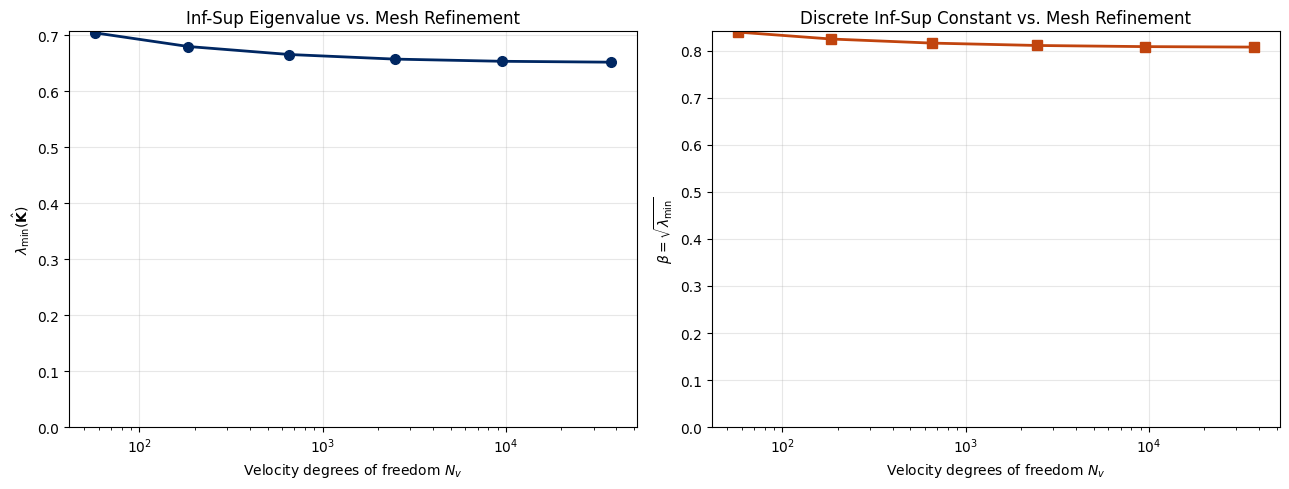

beta ranges from 0.8076 to 0.8394 across 57 to 37505 velocity DOFs.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

Nv_arr = np.array(results['Nv'])
lam_arr = np.array(results['lambda_min'])
beta_arr = np.sqrt(lam_arr)

ax = axes[0]
ax.plot(Nv_arr, lam_arr, 'o-', color='#002762', linewidth=2, markersize=7)
ax.set_xscale('log')
ax.set_xlabel('Velocity degrees of freedom $N_v$')
ax.set_ylabel(r'$\lambda_{\min}(\hat{\mathbf{K}})$')
ax.set_title(r'Inf-Sup Eigenvalue vs. Mesh Refinement')
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)

ax = axes[1]
ax.plot(Nv_arr, beta_arr, 's-', color='#c1440e', linewidth=2, markersize=7)
ax.set_xscale('log')
ax.set_xlabel('Velocity degrees of freedom $N_v$')
ax.set_ylabel(r'$\beta = \sqrt{\lambda_{\min}}$')
ax.set_title(r'Discrete Inf-Sup Constant vs. Mesh Refinement')
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('LBB_stability_P1isoP1.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'beta ranges from {beta_arr.min():.4f} to {beta_arr.max():.4f} '
      f'across {Nv_arr.min()} to {Nv_arr.max()} velocity DOFs.')


---